Resampling된 CT image는 추후 T11/T12 HU 기반 골밀도 분석에 활용될 수 있도록 원래 HU intensity를 유지하여 저장하였다. Segmentation model 학습 시에는 Dataset loading 단계에서 [-1000, 2000] HU windowing을 적용한 뒤 0-1 범위로 normalization하였다. Label mask는 class ID 보존을 위해 normalization을 적용하지 않았다.

image:
  기존 resampled nifti는 HU값 그대로 저장하고, 학습할때 HU windowing + normalization 적용

label:
  그대로 0/1/2 class id 유지, 라벨은 HU windowing/normalization 적용 X

In [1]:
import numpy as np

def apply_hu_window_and_normalize(image, lower=-1000, upper=2000):
    image = np.clip(image, lower, upper)
    image = (image - lower) / (upper - lower)
    return image.astype(np.float32)

In [2]:
import nibabel as nib
import numpy as np

image_path = r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\t11_t12_resampled_1x1x2\images\COLONOG\1.3.6.1.4.1.9328.50.4.0001.nii.gz"
label_path = r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\t11_t12_resampled_1x1x2\labels\COLONOG\1.3.6.1.4.1.9328.50.4.0001_t11_t12.nii.gz"

image = np.asanyarray(nib.load(image_path).dataobj).astype(np.float32)
label = np.asanyarray(nib.load(label_path).dataobj).astype(np.uint8)

image = apply_hu_window_and_normalize(image)

print(image.min(), image.max())
print(np.unique(label))

0.0 1.0
[0 1 2]


In [3]:
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

class T11T12Dataset(Dataset):
    def __init__(self, df, image_root, label_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.label_root = label_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = (
            self.image_root /
            row["source"] /
            row["file_name"]
        )

        label_path = (
            self.label_root /
            row["source"] /
            row["file_name"].replace(".nii.gz", "_t11_t12.nii.gz")
        )

        image = np.asanyarray(nib.load(image_path).dataobj).astype(np.float32)
        label = np.asanyarray(nib.load(label_path).dataobj).astype(np.int64)

        image = apply_hu_window_and_normalize(image)

        image = np.transpose(image, (2, 1, 0))
        label = np.transpose(label, (2, 1, 0))

        image = np.ascontiguousarray(image)
        label = np.ascontiguousarray(label)

        image = torch.from_numpy(image).unsqueeze(0)  # (1, D, H, W)
        label = torch.from_numpy(label)               # (D, H, W)

        if self.transform is not None:
            image, label = self.transform(image, label)

        return image, label

#### 실제 학습 전: Dataset/Dataloader 작성단계에서 crop/patch 로직 추가 필요

## resampled T11/T12 bbox 다시 계산

- 리샘플링 후 spacing이 바뀌었기 때문에 bbox를 다시 계산
- original_spacing = (0.78125, 0.78125, 0.8) -> target_spacing = (1.0, 1.0, 2.0)
    - bbox는 bounding box의 줄임말이고, mask를 감싸는 최소 직육면체입니다.

1. resampled label에서 T11/T12 bbox 재계산
2. bbox_x/y/z size 분포 확인
3. 90/95 percentile 기준으로 crop size 후보 결정
4. source별 bbox 차이 확인
5. crop size 확정

In [5]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RESAMPLED_ROOT = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\t11_t12_resampled_1x1x2")
LABEL_ROOT = RESAMPLED_ROOT / "labels"

WORK_DIR = Path(r"C:\Users\comds\Desktop\졸업작품\vscode_script")

df_t11_t12_final = pd.read_pickle(
    WORK_DIR / "df_t11_t12_final_candidates.pkl"
)

bbox_rows = []

for idx, row in enumerate(df_t11_t12_final.itertuples(index=False), start=1):
    source = row.source
    file_name = row.file_name

    label_path = LABEL_ROOT / source / file_name.replace(".nii.gz", "_t11_t12.nii.gz")

    seg = np.asanyarray(nib.load(label_path).dataobj)

    for label_name, label_value in [("T11", 1), ("T12", 2), ("T11_T12", [1, 2])]:
        if isinstance(label_value, list):
            mask = np.isin(seg, label_value)
        else:
            mask = seg == label_value

        if not mask.any():
            bbox_rows.append({
                "source": source,
                "patient_id": row.patient_id,
                "file_name": file_name,
                "label_name": label_name,
                "exists": False,
            })
            continue

        coords = np.argwhere(mask)

        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)

        bbox_rows.append({
            "source": source,
            "patient_id": row.patient_id,
            "file_name": file_name,
            "label_name": label_name,
            "exists": True,
            "voxel_count": int(mask.sum()),
            "x_min": int(x_min),
            "x_max": int(x_max),
            "y_min": int(y_min),
            "y_max": int(y_max),
            "z_min": int(z_min),
            "z_max": int(z_max),
            "bbox_x_size": int(x_max - x_min + 1),
            "bbox_y_size": int(y_max - y_min + 1),
            "bbox_z_size": int(z_max - z_min + 1),
            "shape": seg.shape,
        })

    if idx % 100 == 0:
        print(f"Processed {idx}/{len(df_t11_t12_final)}")

df_resampled_bbox = pd.DataFrame(bbox_rows)

display(df_resampled_bbox.head())

Processed 100/939
Processed 200/939
Processed 300/939
Processed 400/939
Processed 500/939
Processed 600/939
Processed 700/939
Processed 800/939
Processed 900/939


,source,patient_id,file_name,label_name,exists,voxel_count,x_min,x_max,y_min,y_max,z_min,z_max,bbox_x_size,bbox_y_size,bbox_z_size,shape
0,COLONOG,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,T11,True,16555,169,219,195,263,195,217,51,69,23,"(400, 400, 242)"
1,COLONOG,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,T12,True,19356,174,223,189,261,179,202,50,73,24,"(400, 400, 242)"
2,COLONOG,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,T11_T12,True,35911,169,223,189,263,179,217,55,75,39,"(400, 400, 242)"
3,COLONOG,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,T11,True,29404,166,224,241,335,184,213,59,95,30,"(400, 400, 255)"
4,COLONOG,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,T12,True,32622,166,225,241,328,170,199,60,88,30,"(400, 400, 255)"


In [6]:
display(
    df_resampled_bbox[df_resampled_bbox["exists"]]
    .groupby(["label_name"])[["bbox_x_size", "bbox_y_size", "bbox_z_size"]]
    .describe()
)

bbox_x_size                                                      \
                 count       mean       std   min   25%   50%   75%    max   
label_name                                                                   
T11              939.0  54.976571  5.888760  37.0  51.0  55.0  59.0   81.0   
T11_T12          939.0  56.423855  6.153795  39.0  52.0  56.0  60.0  100.0   
T12              939.0  51.777423  5.966366  36.0  48.0  51.0  55.0  100.0   

           bbox_y_size             ...              bbox_z_size             \
                 count       mean  ...   75%    max       count       mean   
label_name                         ...                                       
T11              939.0  73.159744  ...  78.0  115.0       939.0  24.007455   
T11_T12          939.0  80.358892  ...  85.0  123.0       939.0  39.399361   
T12              939.0  75.743344  ...  81.0  118.0       939.0  25.637913   

                                                    
                 std   min   25%   50%   75%   max  
label_name                                          
T11         3.772438   8.0  22.0  24.0  26.0  44.0  
T11_T12     4.065199  18.0  37.0  40.0  42.0  54.0  
T12         3.514346   9.0  24.0  25.0  27.0  42.0  

[3 rows x 24 columns]

In [7]:
target_bbox = df_resampled_bbox[
    (df_resampled_bbox["exists"]) &
    (df_resampled_bbox["label_name"] == "T11_T12")
].copy()

display(
    target_bbox[["bbox_x_size", "bbox_y_size", "bbox_z_size"]]
    .quantile([0.5, 0.75, 0.9, 0.95, 0.99])
)

,bbox_x_size,bbox_y_size,bbox_z_size
0.50,56.0,80.0,40.0
0.75,60.0,85.0,42.0
0.90,64.0,90.0,44.0
0.95,66.1,93.0,46.0
0.99,72.0,101.0,48.0


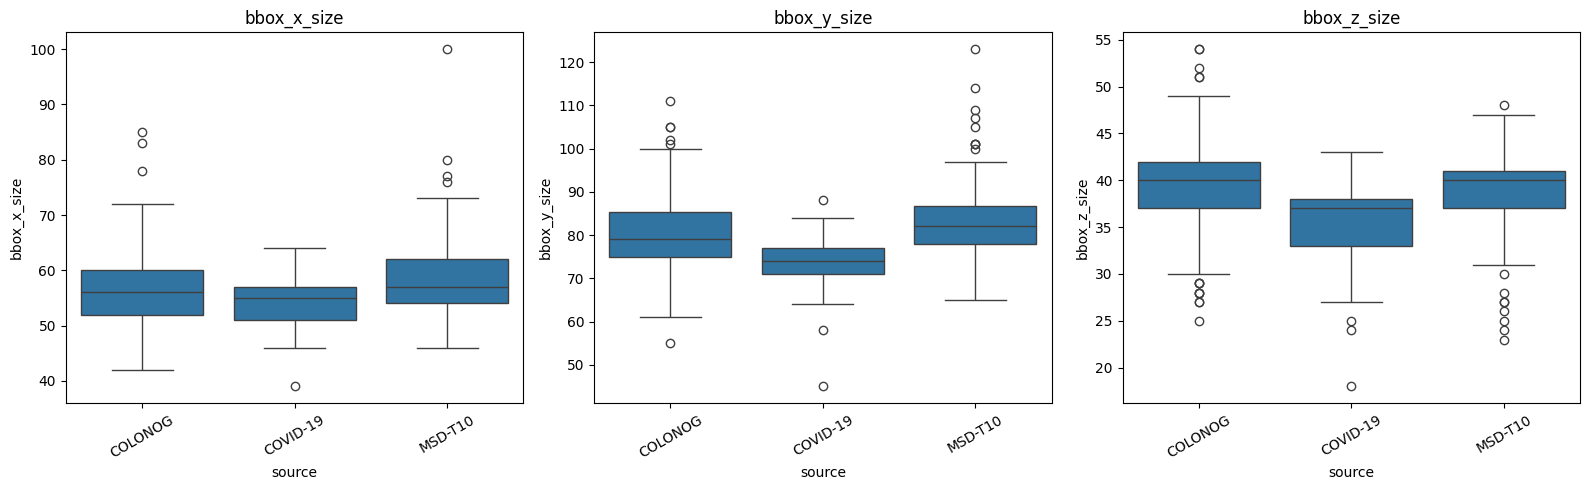

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["bbox_x_size", "bbox_y_size", "bbox_z_size"]):
    sns.boxplot(
        data=target_bbox,
        x="source",
        y=col,
        ax=ax,
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

1. T11_T12 median:
 - x = 56
 - y = 80
 - z = 40

2. T11_T12 95 percentile:
 - x = 66.1
 - y = 93
 - z = 46

3. T11_T12 99 percentile:
 - x = 72
 - y = 101
 - z = 48

4. T11_T12 max:
 - x = 100
 - y = 123
 - z = 54

In [9]:
df_resampled_bbox.to_pickle("df_resampled_bbox.pkl")

df_resampled_bbox.to_csv(
    "df_resampled_bbox.csv",
    index=False,
    encoding="utf-8-sig",
)

- crop_size = (192, 192, 96)  # x, y, z
- random_offset = (40, 40, 15)  # x, y, z

Resampling 후 T11/T12 combined bounding box의 95 percentile은 x=66.1, y=93, z=46 voxels였으며, 99 percentile도 x=72, y=101, z=48 voxels로 확인되었다. 이에 따라 T11/T12와 주변 해부학적 문맥을 포함하면서 GPU 메모리 부담을 줄이기 위해 baseline crop size를 (160, 160, 80) voxels로 설정할 수 있다. 이는 target spacing (1.0, 1.0, 2.0) mm 기준 약 160 mm x 160 mm x 160 mm의 물리적 범위에 해당한다. 하지만 더 넓은 문맥을 포함하기 위해 (192, 192, 96)으로 설정할 예정이다.